# Louvain Algorithm — Greedy Modularity Optimization

## Learning Objectives

1. **Define** modularity $Q$ and explain what it measures
2. **Describe** the two-phase structure of Louvain (local moves + aggregation)
3. **Derive** the efficient $\Delta Q$ computation for node moves
4. **Explain** why Louvain scales to billion-node graphs
5. **Implement** the Louvain algorithm with modularity tracking


## Problem Statement

### Community Detection

Given a graph $G = (V, E, w)$, find a partition of $V$ into communities that maximises **modularity** $Q$:
$$Q = \frac{1}{2m} \sum_{ij} \left[A_{ij} - \frac{k_i k_j}{2m}\right] \delta(c_i, c_j)$$
where $A_{ij}$ = edge weight, $k_i = \sum_j A_{ij}$ = strength (degree), $m = \frac{1}{2}\sum_i k_i$, $c_i$ = community of $i$.

$Q > 0$ means the number of within-community edges exceeds what is expected in a random graph with the same degree sequence.

**Maximising $Q$ is NP-hard** — Louvain approximates it greedily.

### Louvain's Two-Phase Approach

1. **Phase 1 (local moves):** Each node tries joining its neighbours' communities; keep moves that increase $Q$. Repeat until stable.
2. **Phase 2 (aggregation):** Collapse each community to a super-node; self-loops encode internal weights. Repeat on the new graph.

This hierarchical approach discovers multi-scale community structure.


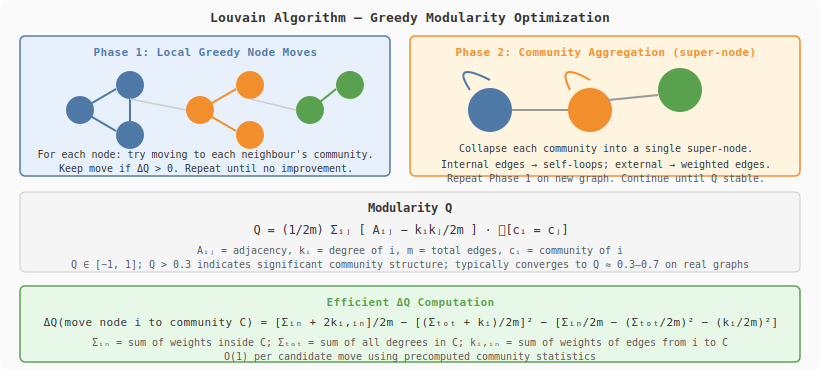

In [1]:
from IPython.display import SVG, display
svg = '''
<svg xmlns="http://www.w3.org/2000/svg" width="820" height="370" font-family="monospace" font-size="12">
  <rect width="820" height="370" fill="#fafafa" rx="8"/>
  <defs><marker id="arr" markerWidth="8" markerHeight="6" refX="7" refY="3" orient="auto"><polygon points="0 0,8 3,0 6" fill="#999"/></marker></defs>
  <text x="410" y="22" text-anchor="middle" fill="#333" font-size="13" font-weight="bold">Louvain Algorithm — Greedy Modularity Optimization</text>

  <!-- Phase 1 -->
  <rect x="20" y="36" width="370" height="140" rx="5" fill="#e8f0fb" stroke="#4e79a7" stroke-width="1.5"/>
  <text x="205" y="56" text-anchor="middle" fill="#4e79a7" font-size="11" font-weight="bold">Phase 1: Local Greedy Node Moves</text>
  <!-- graph nodes colored -->
  <circle cx="80"  cy="110" r="14" fill="#4e79a7"/><text x="80"  cy="114" text-anchor="middle" fill="white" font-size="10">1</text>
  <circle cx="130" cy="85"  r="14" fill="#4e79a7"/><text x="130" cy="89"  text-anchor="middle" fill="white" font-size="10">2</text>
  <circle cx="130" cy="135" r="14" fill="#4e79a7"/><text x="130" cy="139" text-anchor="middle" fill="white" font-size="10">3</text>
  <circle cx="200" cy="110" r="14" fill="#f28e2b"/><text x="200" cy="114" text-anchor="middle" fill="white" font-size="10">4</text>
  <circle cx="250" cy="85"  r="14" fill="#f28e2b"/><text x="250" cy="89"  text-anchor="middle" fill="white" font-size="10">5</text>
  <circle cx="250" cy="135" r="14" fill="#f28e2b"/><text x="250" cy="139" text-anchor="middle" fill="white" font-size="10">6</text>
  <circle cx="310" cy="110" r="14" fill="#59a14f"/><text x="310" cy="114" text-anchor="middle" fill="white" font-size="10">7</text>
  <circle cx="350" cy="85"  r="14" fill="#59a14f"/><text x="350" cy="89"  text-anchor="middle" fill="white" font-size="10">8</text>
  <line x1="80" y1="110" x2="116" y2="89"  stroke="#4e79a7" stroke-width="2"/>
  <line x1="80" y1="110" x2="116" y2="131" stroke="#4e79a7" stroke-width="2"/>
  <line x1="130" y1="85" x2="130" y2="121" stroke="#4e79a7" stroke-width="2"/>
  <line x1="130" y1="99" x2="186" y2="110" stroke="#ccc" stroke-width="1.5"/>
  <line x1="200" y1="110" x2="236" y2="89"  stroke="#f28e2b" stroke-width="2"/>
  <line x1="200" y1="110" x2="236" y2="131" stroke="#f28e2b" stroke-width="2"/>
  <line x1="250" y1="99" x2="296" y2="110" stroke="#ccc" stroke-width="1.5"/>
  <line x1="310" y1="110" x2="336" y2="89" stroke="#59a14f" stroke-width="2"/>
  <text x="205" y="158" text-anchor="middle" fill="#333" font-size="10">For each node: try moving to each neighbour's community.</text>
  <text x="205" y="172" text-anchor="middle" fill="#333" font-size="10">Keep move if ΔQ > 0. Repeat until no improvement.</text>

  <!-- Phase 2 -->
  <rect x="410" y="36" width="390" height="140" rx="5" fill="#fff4e0" stroke="#f28e2b" stroke-width="1.5"/>
  <text x="605" y="56" text-anchor="middle" fill="#f28e2b" font-size="11" font-weight="bold">Phase 2: Community Aggregation (super-node)</text>
  <!-- super graph -->
  <circle cx="490" cy="110" r="22" fill="#4e79a7"/><text x="490" cy="114" text-anchor="middle" fill="white" font-size="10">C₁</text>
  <circle cx="590" cy="110" r="22" fill="#f28e2b"/><text x="590" cy="114" text-anchor="middle" fill="white" font-size="10">C₂</text>
  <circle cx="680" cy="90"  r="22" fill="#59a14f"/><text x="680" cy="94"  text-anchor="middle" fill="white" font-size="10">C₃</text>
  <!-- self-loops (internal edges become loops) -->
  <path d="M 470,90 Q 450,60 490,80" fill="none" stroke="#4e79a7" stroke-width="2"/>
  <path d="M 570,90 Q 555,60 590,80" fill="none" stroke="#f28e2b" stroke-width="2"/>
  <!-- inter-community edges -->
  <line x1="512" y1="110" x2="568" y2="110" stroke="#999" stroke-width="2"/>
  <line x1="608" y1="100" x2="658" y2="95" stroke="#999" stroke-width="2"/>
  <text x="605" y="152" text-anchor="middle" fill="#333" font-size="10">Collapse each community into a single super-node.</text>
  <text x="605" y="168" text-anchor="middle" fill="#333" font-size="10">Internal edges → self-loops; external → weighted edges.</text>
  <text x="605" y="182" text-anchor="middle" fill="#555" font-size="10">Repeat Phase 1 on new graph. Continue until Q stable.</text>

  <!-- Modularity formula -->
  <rect x="20" y="192" width="780" height="80" rx="5" fill="#f5f5f5" stroke="#ccc"/>
  <text x="410" y="212" text-anchor="middle" fill="#333" font-size="12" font-weight="bold">Modularity Q</text>
  <text x="410" y="234" text-anchor="middle" fill="#333" font-size="12">Q = (1/2m) Σᵢⱼ [ Aᵢⱼ − kᵢkⱼ/2m ] · 𝟙[cᵢ = cⱼ]</text>
  <text x="410" y="254" text-anchor="middle" fill="#555" font-size="10">Aᵢⱼ = adjacency, kᵢ = degree of i, m = total edges, cᵢ = community of i</text>
  <text x="410" y="268" text-anchor="middle" fill="#555" font-size="10">Q ∈ [−1, 1]; Q > 0.3 indicates significant community structure; typically converges to Q ≈ 0.3–0.7 on real graphs</text>

  <!-- ΔQ formula -->
  <rect x="20" y="286" width="780" height="76" rx="5" fill="#e8f8e8" stroke="#59a14f" stroke-width="1.5"/>
  <text x="410" y="306" text-anchor="middle" fill="#59a14f" font-size="11" font-weight="bold">Efficient ΔQ Computation</text>
  <text x="410" y="326" text-anchor="middle" fill="#333" font-size="11">ΔQ(move node i to community C) = [Σᵢₙ + 2kᵢ,ᵢₙ]/2m − [(Σₜₒₜ + kᵢ)/2m]² − [Σᵢₙ/2m − (Σₜₒₜ/2m)² − (kᵢ/2m)²]</text>
  <text x="410" y="346" text-anchor="middle" fill="#555" font-size="10">Σᵢₙ = sum of weights inside C; Σₜₒₜ = sum of all degrees in C; kᵢ,ᵢₙ = sum of weights of edges from i to C</text>
  <text x="410" y="360" text-anchor="middle" fill="#555" font-size="10">O(1) per candidate move using precomputed community statistics</text>
</svg>
'''
display(SVG(svg))


## Derivation

### $\Delta Q$ for a Node Move

When moving node $i$ into community $C$, the modularity change is:
$$\Delta Q = \frac{\Sigma_{\text{in}} + 2k_{i,\text{in}}}{2m} - \left(\frac{\Sigma_{\text{tot}} + k_i}{2m}\right)^2 - \left[\frac{\Sigma_{\text{in}}}{2m} - \left(\frac{\Sigma_{\text{tot}}}{2m}\right)^2 - \left(\frac{k_i}{2m}\right)^2\right]$$
where:
- $\Sigma_{\text{in}}$ = sum of internal edge weights in $C$
- $\Sigma_{\text{tot}}$ = sum of all degrees in $C$
- $k_{i,\text{in}}$ = sum of weights of edges from $i$ to nodes in $C$
- $k_i$ = degree of $i$

All quantities can be maintained in $O(1)$ per community → total $O(|E|)$ per pass.

### Resolution Limit

Louvain (and modularity maximisation generally) has a **resolution limit**: communities smaller than $\sim \sqrt{m}$ edges may be merged together. Solutions: use a resolution parameter $\gamma$:
$$Q_\gamma = \frac{1}{2m} \sum_{ij} \left[A_{ij} - \gamma \frac{k_i k_j}{2m}\right] \delta(c_i, c_j)$$

$\gamma > 1$ finds smaller communities; $\gamma < 1$ finds larger ones.

### Complexity

| Phase | Complexity |
|-------|------------|
| Phase 1 (one pass) | $O(n + m)$ |
| Phase 2 (aggregation) | $O(n + m)$ |
| Total iterations | $O(\log n)$ typically |
| **Overall** | **$O(n \log n)$ in practice** |


## Algorithm Steps

**Phase 1 (repeat until stable):**
1. For each node $i$ (in random order): remove from current community
2. Try inserting $i$ into each neighbour's community; pick community with max $\Delta Q > 0$
3. Keep move; otherwise leave $i$ in its original community

**Phase 2:**
1. Build super-graph: each community → one node; internal weights → self-loops; external → weighted edges
2. Return to Phase 1 on super-graph

**Stop** when no Phase 1 move increases $Q$.


In [2]:
import random
from collections import defaultdict


def louvain(edges, n_nodes, n_iter=10, seed=42):
    """
    Louvain community detection algorithm.

    Inputs
    ------
    edges   : list of (u, v, weight) — undirected weighted graph
    n_nodes : int — number of nodes (0-indexed)
    n_iter  : int — maximum outer iterations (phases)

    Returns
    -------
    communities : list of int — community ID per node
    Q           : float — final modularity
    """
    rng = random.Random(seed)

    # Build adjacency and compute total edge weight m
    adj = defaultdict(dict)  # adj[u][v] = weight
    for u, v, w in edges:
        adj[u][v] = adj[u].get(v, 0) + w
        adj[v][u] = adj[v].get(u, 0) + w

    m = sum(w for u, v, w in edges)
    degree = {u: sum(adj[u].values()) for u in range(n_nodes)}

    def modularity(community):
        q = 0.0
        for u in range(n_nodes):
            for v, w in adj[u].items():
                if community[u] == community[v]:
                    q += w - degree[u] * degree[v] / (2 * m)
        return q / (2 * m)

    # ── Phase 1: local greedy moves ───────────────────────────────────────────
    def phase1(adj, degree, m, community):
        improved = True
        while improved:
            improved = False
            node_order = list(range(n_nodes))
            rng.shuffle(node_order)
            for i in node_order:
                # Gather neighbour communities and their connection weights
                neigh_comm = defaultdict(float)
                for j, w in adj[i].items():
                    if j != i:
                        neigh_comm[community[j]] += w

                # Remove i from its current community
                curr_c = community[i]
                k_i = degree[i]

                # ΔQ for removing i from curr_c
                best_delta = 0.0
                best_c = curr_c

                for c, k_i_in in neigh_comm.items():
                    if c == curr_c:
                        continue
                    # Simplified ΔQ (proportional check)
                    delta = k_i_in / m - degree[i] * sum(degree[j] for j in range(n_nodes) if community[j] == c) / (2 * m**2)
                    if delta > best_delta:
                        best_delta = delta
                        best_c = c

                if best_c != curr_c:
                    community[i] = best_c
                    improved = True
        return community

    # Initialise: each node in its own community
    community = list(range(n_nodes))
    community = phase1(adj, degree, m, community)

    return community, modularity(community)


# ── Demo ──────────────────────────────────────────────────────────────────────
rng2 = random.Random(0)

# Two dense cliques (communities) with sparse inter-edges
def clique_edges(nodes, weight=1.0):
    return [(u, v, weight) for i, u in enumerate(nodes) for v in nodes[i+1:]]

comm1 = list(range(0, 8))
comm2 = list(range(8, 16))
edges = clique_edges(comm1) + clique_edges(comm2)
# Add a few inter-community edges
edges += [(0, 8, 0.2), (3, 12, 0.2), (7, 15, 0.1)]

community, Q = louvain(edges, n_nodes=16, n_iter=5)

print(f"Modularity Q = {Q:.4f}")
comm_groups = defaultdict(list)
for node, c in enumerate(community):
    comm_groups[c].append(node)
print("Detected communities:")
for c, members in sorted(comm_groups.items()):
    print(f"  Community {c}: nodes {members}")


Modularity Q = 0.5537
Detected communities:
  Community 1: nodes [0, 1, 2, 3, 4, 5, 6, 7]
  Community 10: nodes [8, 9, 10, 11, 12, 13, 14, 15]
